# Где дешевле жить? Предсказание цен в Airbnb - генерируем признаки и интерпретируем результаты модели

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Часть 1. EDA

In [2]:
data = pd.read_csv('AB_NYC_2019.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [3]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Выкидываем ненужные признаки: id, name, host_id, host_name, last_review

In [4]:
cols_2_drop = ['id', 'name', 'host_id', 'host_name', 'last_review']
data = data.drop(cols_2_drop, axis=1)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


Признак reviews_per_month из 48895 имеет 38843 Non-Null значения. Производим замену Null на 0, так как пропуск фактически означает отсутствие отзывов (number_of_reviews = 0)

In [6]:
data.loc[:, 'reviews_per_month'] = data.reviews_per_month.fillna(0)

In [7]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


### Распределения числовых признаков

In [8]:
data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


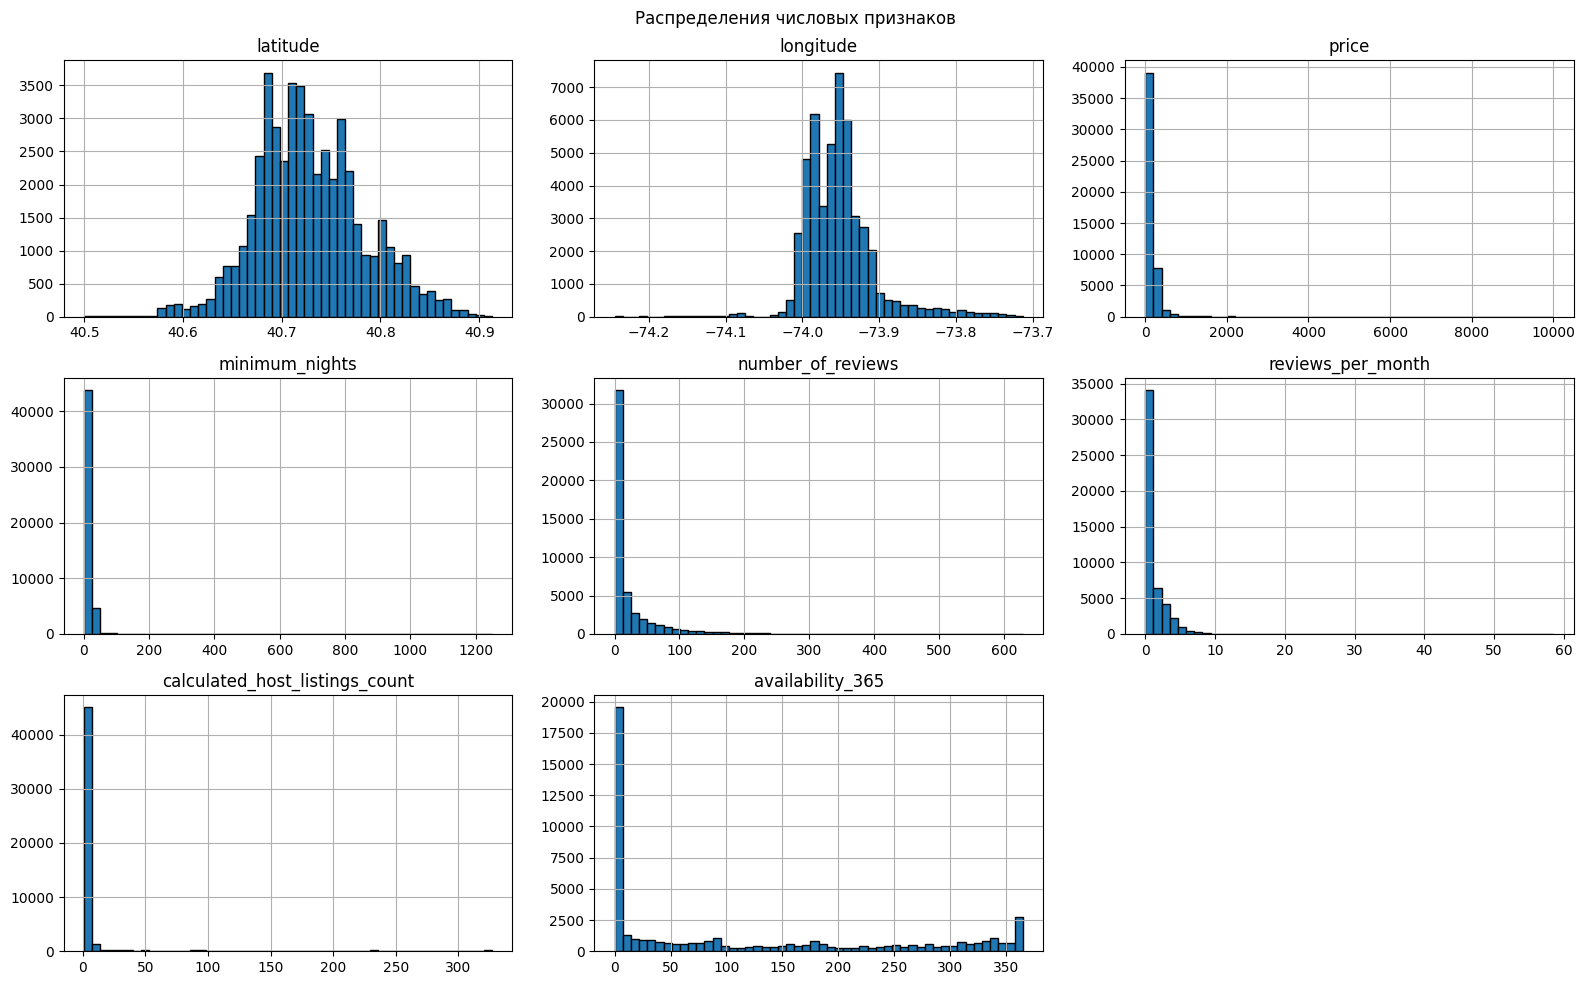

In [9]:
numeric_cols = [
    'latitude',
    'longitude',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

data[numeric_cols].hist(
    bins=50,
    figsize=(16, 10),
    edgecolor='black'
)

plt.suptitle('Распределения числовых признаков')
plt.tight_layout()
plt.show()

### Матрицы попарных корреляций

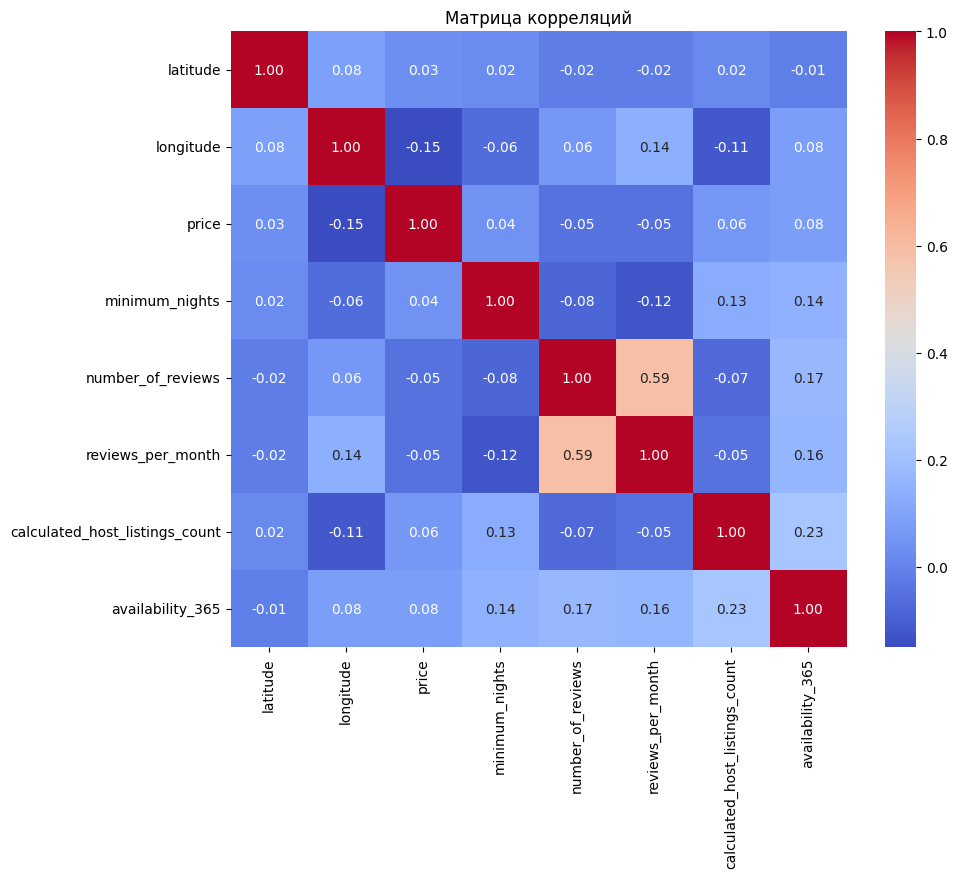

In [10]:
corr = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)

plt.title('Матрица корреляций')
plt.show()

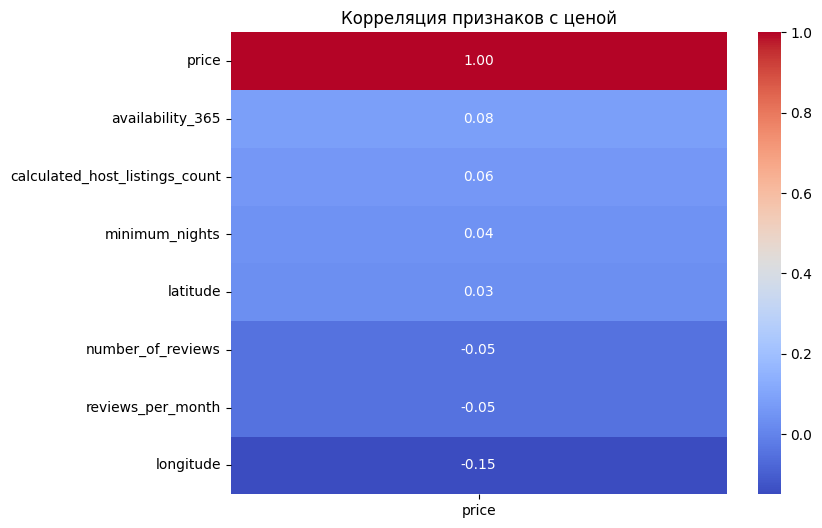

In [11]:
plt.figure(figsize=(8, 6))

corr_price = corr[['price']].sort_values(
    by='price',
    ascending=False
)

sns.heatmap(
    corr_price,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Корреляция признаков с ценой')
plt.show()

Между признаками number_of_reviews и reviews_per_month обнаружена умеренная положительная корреляция (0.59). Значение свидетельствует об умеренной связи, поэтому оба признака могут быть сохранены для дальнейшего моделирования.

### Построение Pair plots

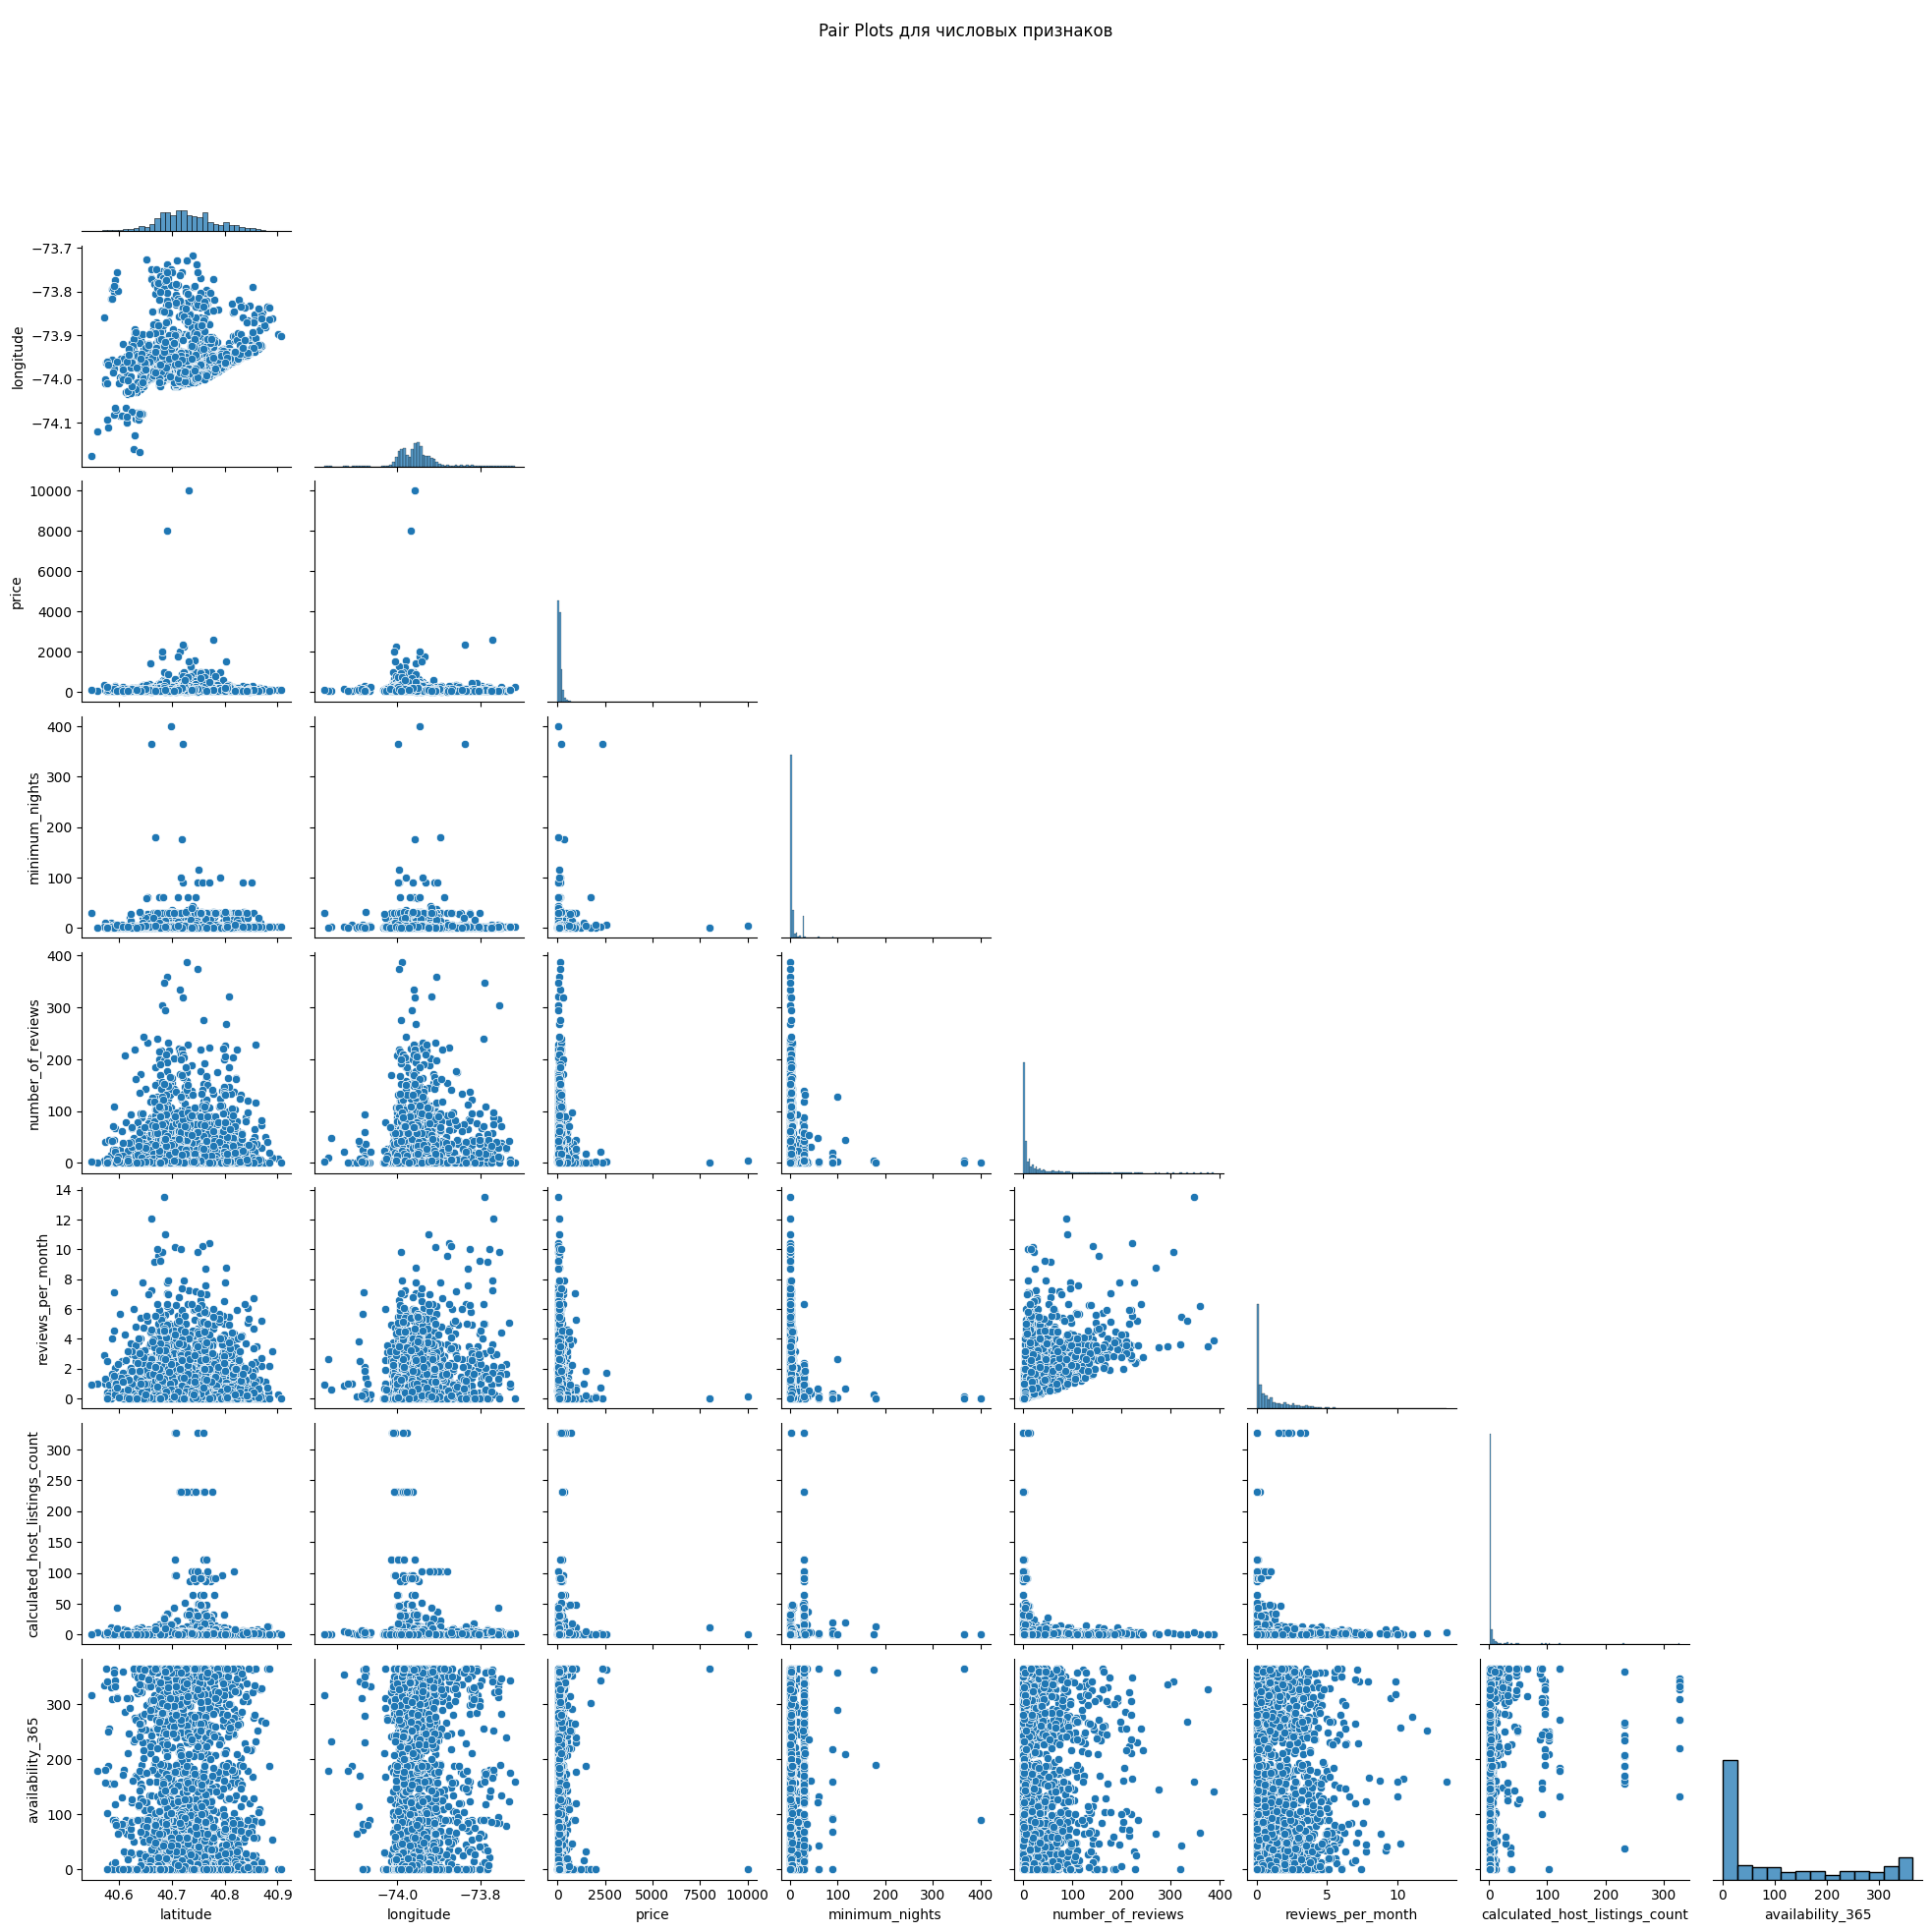

In [12]:
sample_df = data[numeric_cols].sample(
    n=3000,
    random_state=42
)

sns.pairplot(
    sample_df,
    diag_kind='hist',
    corner=True
)

plt.suptitle('Pair Plots для числовых признаков')
plt.show()

# Часть 2. Preprocessing & Feature Engineering

In [13]:
print(f"{data['price'].describe(percentiles=[0.95, 0.99])}\n")
print(f"{data['minimum_nights'].describe(percentiles=[0.95, 0.99])}\n")
print(f"{data['number_of_reviews'].describe(percentiles=[0.95, 0.99])}\n")
print(f"{data['calculated_host_listings_count'].describe(percentiles=[0.95, 0.99])}\n")

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
50%        106.000000
95%        355.000000
99%        799.000000
max      10000.000000
Name: price, dtype: float64

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
50%          3.000000
95%         30.000000
99%         45.000000
max       1250.000000
Name: minimum_nights, dtype: float64

count    48895.000000
mean        23.274466
std         44.550582
min          0.000000
50%          5.000000
95%        114.000000
99%        214.000000
max        629.000000
Name: number_of_reviews, dtype: float64

count    48895.000000
mean         7.143982
std         32.952519
min          1.000000
50%          1.000000
95%         15.000000
99%        232.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64



### Обработка выбросов

price: медиана 106$, максимум 10000$;
minimum_nights: присутствуют экстремальные значения;
number_of_reviews и calculated_host_listings_count также содержат длинный хвост.

Ограничиваем по 99-му перцентилю.

In [14]:
p99 = data['price'].quantile(0.99)
print('price: ' + str(p99) + '\n')
p99 = data['minimum_nights'].quantile(0.99)
print('minimum_nights: ' + str(p99) + '\n')
p99 = data['number_of_reviews'].quantile(0.99)
print('number_of_reviews: ' + str(p99) + '\n')
p99 = data['calculated_host_listings_count'].quantile(0.99)
print('calculated_host_listings_count: ' + str(p99) + '\n')

price: 799.0

minimum_nights: 45.0

number_of_reviews: 214.0

calculated_host_listings_count: 232.0



In [15]:
data['price'] = data['price'].clip(upper=799)
data['minimum_nights'] = data['minimum_nights'].clip(upper=45)
data['number_of_reviews'] = data['number_of_reviews'].clip(upper=214)
data['calculated_host_listings_count'] = data['calculated_host_listings_count'].clip(upper=232)

In [16]:
data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,143.956233,6.116760,22.604765,1.090910,6.508641,112.781327
std,0.054530,0.046157,121.935067,9.244957,40.410496,1.597283,27.191540,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,799.000000,45.000000,214.000000,58.500000,232.000000,365.000000


Вводим новую переменную «расстояние до Манхэттена» по евклидовой метрике

In [17]:
manhattan = data[data['neighbourhood_group'] == 'Manhattan']

manhattan_lat = manhattan['latitude'].mean()
manhattan_lon = manhattan['longitude'].mean()

data['distance_to_manhattan'] = (
    (data['latitude'] - manhattan_lat) ** 2 +
    (data['longitude'] - manhattan_lon) ** 2
) ** 0.5

### Кодирование категориальных признаков

In [18]:
data = pd.get_dummies(
    data,
    columns=['room_type'],
    drop_first=True
)

data = pd.get_dummies(
    data,
    columns=['neighbourhood_group'],
    drop_first=True
)

top20 = data['neighbourhood'].value_counts().head(20).index
data['neighbourhood'] = data['neighbourhood'].where(data['neighbourhood'].isin(top20), 'Other')
data = pd.get_dummies(data, columns=['neighbourhood'], drop_first=True)

### Шкалирование непрерывных переменных

In [19]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'distance_to_manhattan'
]

scaler = StandardScaler()

data[num_cols] = scaler.fit_transform(data[num_cols])

In [20]:
data.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,distance_to_manhattan,room_type_Private room,...,neighbourhood_Harlem,neighbourhood_Hell's Kitchen,neighbourhood_Lower East Side,neighbourhood_Midtown,neighbourhood_Other,neighbourhood_Upper East Side,neighbourhood_Upper West Side,neighbourhood_Washington Heights,neighbourhood_West Village,neighbourhood_Williamsburg
0,-1.493849,-0.437652,149,-0.553471,-0.336668,-0.551511,-0.018706,1.916250,1.065699,True,...,False,False,False,False,True,False,False,False,False,False
1,0.452436,-0.684639,225,-0.553471,0.554199,-0.445079,-0.165812,1.840275,-1.253769,False,...,False,False,False,True,False,False,False,False,False,False
2,1.468399,0.222497,150,-0.337134,-0.559384,-0.682986,-0.202589,1.916250,-0.349473,True,...,True,False,False,False,False,False,False,False,False,False
3,-0.803398,-0.164450,89,-0.553471,4.736324,2.221978,-0.202589,0.617065,0.247645,False,...,False,False,False,False,False,False,False,False,False,False
4,1.275660,0.177216,80,0.420043,-0.336668,-0.620379,-0.202589,-0.856865,-0.562324,False,...,False,False,False,False,False,False,False,False,False,False


В ходе EDA были выявлены сильная положительная асимметрия признаков price, minimum_nights, number_of_reviews и calculated_host_listings_count, а также наличие выбросов. Для уменьшения влияния экстремальных значений применено ограничение по 99-му процентилю. Категориальные признаки room_type и neighbourhood_group закодированы методом One-Hot Encoding. Для признака neighbourhood, имеющего огромное количество уникальных значений, использовано Top-N + One-Hot Encoding. Числовые признаки масштабированы методом StandardScaler. Дополнительно сформированы производные признаки, характеризующие доступность объекта и его расположение. Это позволило получить набор признаков, пригодный для дальнейшего построения моделей.

# Часть 3. Моделирование

In [21]:
X = data.drop('price', axis=1)
y = data['price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

### Линейная регрессия

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

### RidgeCV

In [29]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(
    alphas=np.logspace(-3, 3, 100),
    cv=5
)

ridge.fit(X_train, y_train)

RidgeCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=5)

### LassoCV

In [30]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=10000
)

lasso.fit(X_train, y_train)

LassoCV(cv=5, max_iter=10000, random_state=42)

### ElasticNetCV

In [31]:
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(
    cv=5,
    random_state=42,
    max_iter=10000
)

elastic.fit(X_train, y_train)

ElasticNetCV(cv=5, max_iter=10000, random_state=42)

### Оценка качества

In [32]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

models = {
    'Linear Regression': lr,
    'RidgeCV': ridge,
    'LassoCV': lasso,
    'ElasticNetCV': elastic
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': root_mean_squared_error(y_test, pred)
    })

results = pd.DataFrame(results)
print(results)

               Model        R2        MAE       RMSE
0  Linear Regression  0.344458  57.638800  97.999369
1            RidgeCV  0.344397  57.618070  98.003966
2            LassoCV  0.344217  57.601795  98.017371
3       ElasticNetCV  0.324749  58.399751  99.461649


Все модели объясняют примерно 34% вариации цены (R² ≈ 0.34). Linear Regression, RidgeCV и LassoCV показали практически одинаковое качество.
ElasticNetCV оказался немного хуже по всем метрикам. Регуляризация (Ridge и Lasso) не дала заметного улучшения, что говорит об отсутствии сильной линейной зависимости между объясняющими признаками. Несмотря на использование регуляризованных моделей RidgeCV, LassoCV и ElasticNetCV, существенного улучшения качества по сравнению с обычной линейной регрессией получено не было. Это свидетельствует о том, что основным ограничением является сложный нелинейный характер зависимости стоимости жилья от факторов, представленных в наборе данных. Поскольку LassoCV обеспечивает сопоставимое качество и одновременно выполняет отбор признаков за счёт зануления неинформативных коэффициентов, данная модель может быть выбрана в качестве итоговой.

In [33]:
coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})

coef['Importance'] = coef['Coefficient'].abs()

coef = coef.sort_values(
    'Importance',
    ascending=False
)

print(coef.head(20))

                              Feature  Coefficient  Importance
9               room_type_Shared room  -126.617857  126.617857
8              room_type_Private room   -97.083792   97.083792
27              neighbourhood_Midtown    59.919333   59.919333
11      neighbourhood_group_Manhattan    43.480802   43.480802
13  neighbourhood_group_Staten Island   -37.803298   37.803298
32         neighbourhood_West Village    35.416612   35.416612
31   neighbourhood_Washington Heights   -33.613933   33.613933
19          neighbourhood_East Harlem   -27.714331   27.714331
33         neighbourhood_Williamsburg    27.618044   27.618044
24               neighbourhood_Harlem   -27.088893   27.088893
17         neighbourhood_Clinton Hill    23.177829   23.177829
16              neighbourhood_Chelsea    22.107397   22.107397
6                    availability_365    22.020980   22.020980
29      neighbourhood_Upper East Side   -17.112756   17.112756
26      neighbourhood_Lower East Side   -16.390077   16

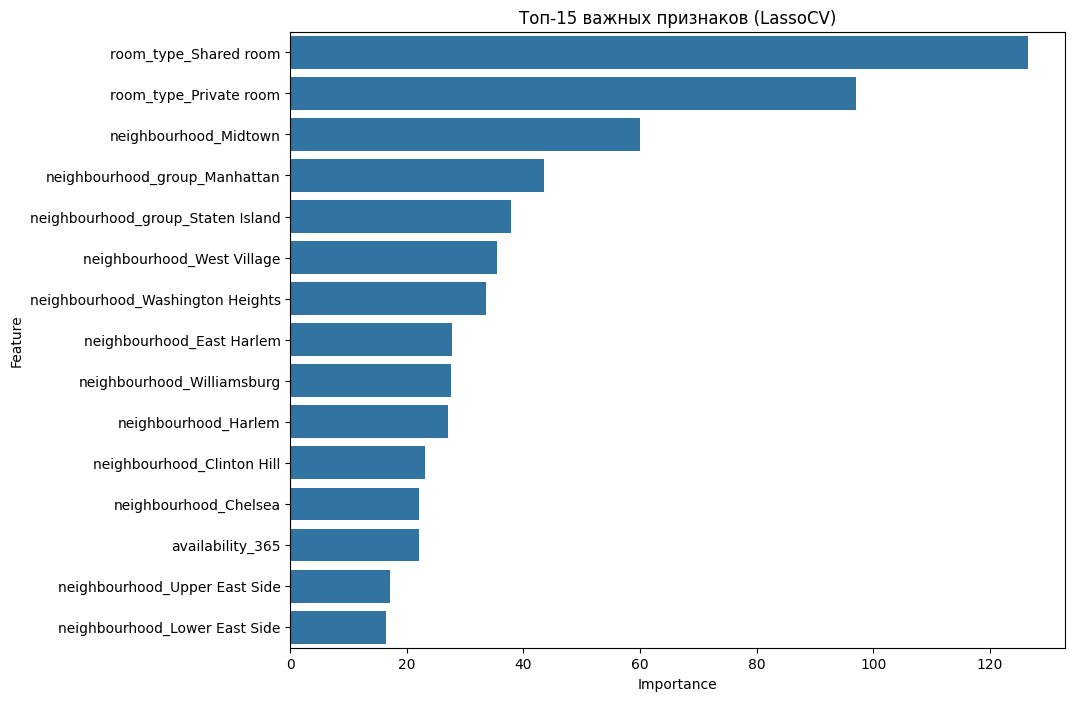

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.barplot(
    data=coef.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Топ-15 важных признаков (LassoCV)')
plt.show()

### Попыка модификации данных для улучшения результатов

Обратив внимание на распределение целевой переменной, можно попробовать логарифмировать цену и произвести повторное моделирование

In [52]:
data['price_log'] = np.log1p(data['price'])

X = data.drop(['price', 'price_log'], axis=1)
y = data['price_log']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

### Линейная регрессия

In [54]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

### RidgeCV

In [55]:
ridge = RidgeCV(
    alphas=np.logspace(-3, 3, 100),
    cv=5
)

ridge.fit(X_train, y_train)

RidgeCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=5)

### LassoCV

In [56]:
lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=10000
)

lasso.fit(X_train, y_train)

LassoCV(cv=5, max_iter=10000, random_state=42)

### ElasticNetCV

In [57]:
elastic = ElasticNetCV(
    cv=5,
    random_state=42,
    max_iter=10000
)

elastic.fit(X_train, y_train)

ElasticNetCV(cv=5, max_iter=10000, random_state=42)

### Оценка качества

In [58]:
models = {
    'Linear Regression': lr,
    'RidgeCV': ridge,
    'LassoCV': lasso,
    'ElasticNetCV': elastic
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': root_mean_squared_error(y_test, pred)
    })

results = pd.DataFrame(results)
print(results)

               Model        R2       MAE      RMSE
0  Linear Regression  0.554947  0.332785  0.448418
1            RidgeCV  0.554964  0.332767  0.448410
2            LassoCV  0.554661  0.332767  0.448562
3       ElasticNetCV  0.554640  0.332751  0.448573


Сравнение до и после логарифмирования:

| Модель до         |     R² |       MAE |  RMSE |
| ----------------- | -----: | --------: | ----: |
| Linear Regression | 0.3445 |     57.64 | 98.00 |
| RidgeCV           | 0.3444 |     57.62 | 98.00 |
| LassoCV           | 0.3442 | **57.60** | 98.02 |
| ElasticNetCV      | 0.3247 |     58.40 | 99.46 |



| Модель после      |          R² |         MAE |        RMSE |
| ----------------- | ----------: | ----------: | ----------: |
| Linear Regression |     0.55495 |     0.33279 |     0.44842 |
| RidgeCV           | **0.55496** |     0.33277 | **0.44841** |
| LassoCV           |     0.55466 |     0.33277 |     0.44856 |
| ElasticNetCV      |     0.55464 | **0.33275** |     0.44857 |


Модели "после" объясняют около 55.5% вариации логарифма цены.
Различия между моделями минимальны.
RidgeCV показывает лучший R² и RMSE, но превосходство очень небольшое.
Регуляризация практически не влияет на качество, что говорит об отсутствии серьёзной сильной линейной зависимости между объясняющими признаками.

Для прогнозирования стоимости жилья были построены модели Linear Regression, RidgeCV, LassoCV и ElasticNetCV. Наилучший результат показала модель RidgeCV с коэффициентом детерминации R
2
=0.555. Все модели продемонстрировали близкие значения метрик, что свидетельствует об устойчивости результатов и отсутствии существенного влияния регуляризации. Модель RidgeCV была выбрана в качестве итоговой для дальнейшего анализа важности признаков.

### Интерпретация важности признаков

In [60]:
coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge.coef_
})

coef['Importance'] = np.abs(coef['Coefficient'])

coef = coef.sort_values(
    'Importance',
    ascending=False
)

print(coef.head(15))

                              Feature  Coefficient  Importance
9               room_type_Shared room    -1.143171    1.143171
8              room_type_Private room    -0.730480    0.730480
11      neighbourhood_group_Manhattan     0.311486    0.311486
13  neighbourhood_group_Staten Island    -0.242323    0.242323
31   neighbourhood_Washington Heights    -0.235667    0.235667
27              neighbourhood_Midtown     0.230884    0.230884
33         neighbourhood_Williamsburg     0.187470    0.187470
24               neighbourhood_Harlem    -0.161211    0.161211
19          neighbourhood_East Harlem    -0.150234    0.150234
32         neighbourhood_West Village     0.150055    0.150055
17         neighbourhood_Clinton Hill     0.147582    0.147582
22             neighbourhood_Flatbush    -0.144267    0.144267
6                    availability_365     0.112824    0.112824
23           neighbourhood_Greenpoint     0.106534    0.106534
16              neighbourhood_Chelsea     0.099685    0

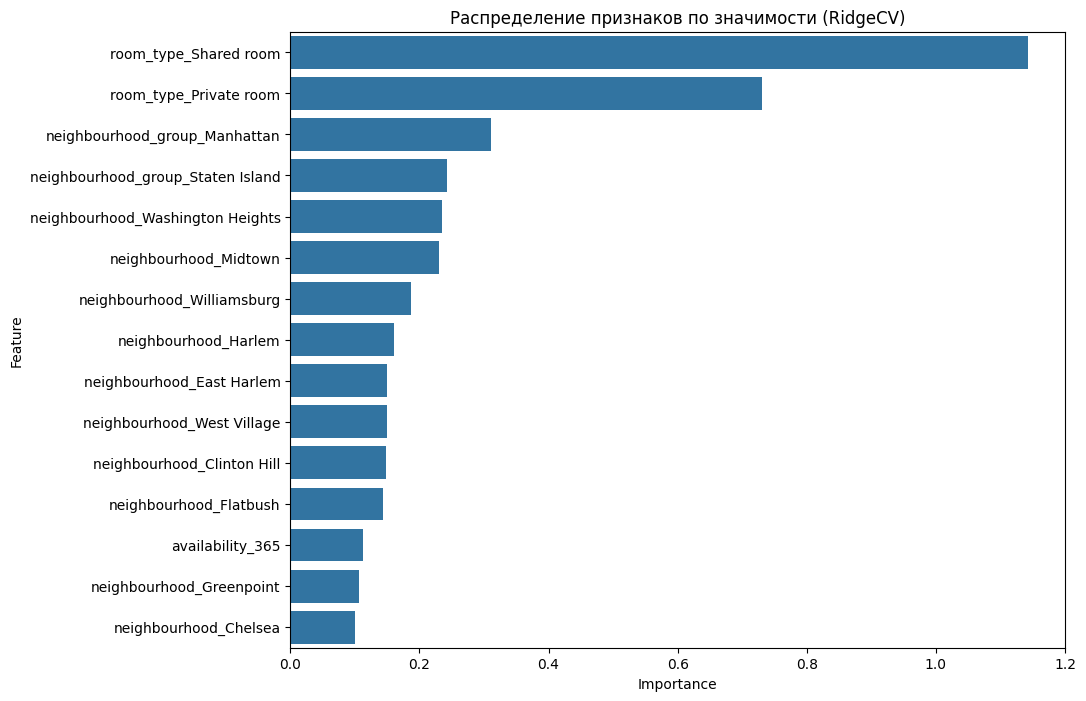

In [62]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=coef.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Распределение признаков по значимости (RidgeCV)')
plt.show()

## Выводы

Анализ коэффициентов модели RidgeCV показал, что наибольшее влияние на стоимость жилья оказывает тип объекта размещения. Наиболее дорогими являются объекты категории Entire home/apt, тогда как Private room и Shared room характеризуются существенно более низкой стоимостью. Существенное влияние оказывает местоположение: принадлежность к району Manhattan увеличивает прогнозируемую цену, а такие районы как Midtown, Williamsburg и West Village дополнительно повышают стоимость аренды. Среди числовых признаков заметное влияние оказывает показатель availability_365, характеризующий доступность объекта в течение года.